# Tutorial 31 — Platinum: SCDM for spin-orbit-coupled bands

The waw-native reimagining of Wannier90 tutorial 31 -- `auto_projections`, wannier90's automatic-initial-guess machinery (SCDM, Selected Columns of the Density Matrix), extended to a **spinor** (noncollinear + spin-orbit-coupled) system. This is the SAME fcc platinum system as tutorial 29 -- identical structure, pseudopotential, and disentanglement windows -- but Wannierised with SCDM instead of tutorial 29's explicit analytic $d;s;p$ trial orbitals, followed by a plain interpolated band structure (no postw90 physics module here, unlike tutorial 29's spin Hall conductivity).

No new capability: `waw.interfaces.quantum_espresso.generate_overlaps`'s `scdm_entanglement`/`scdm_mu`/`scdm_sigma` already work for spinor systems (first exercised for tutorials 17-19's spin-polarised iron); tutorial 27 already validated the `isolated`/`erfc`/`gaussian` SCDM modes for a non-spinor system. This tutorial is the direct spinor/SOC analogue of tutorial 27, and a live A/B comparison against tutorial 29's analytic-projection Wannierisation of the exact same system.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT, Wannierised via SCDM
Same fcc Pt, $a=3.92$ Å, fully-relativistic PAW pseudopotential, and 40→18 disentanglement window as tutorial 29 -- but `scdm_entanglement='erfc'` (`scdm_mu=35 eV, scdm_sigma=5 eV`, wannier90's own tutorial 31 values) builds the initial guess automatically from the density matrix, with NO analytic `projections=` block at all.

In [2]:
from ase.build import bulk
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands

atoms = bulk('Pt', 'fcc', a=3.92)
MP_GRID = (7, 7, 7)   # matches the real tutorial's own coarser mesh
WORK = HERE / 'runs' / 'pt_scdm'

SOC = dict(noncolin=True, lspinorb=True, ecutrho=1080,
           occupations='smearing', smearing='mv', degauss=0.002)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'pt_scdm',
    ecutwfc=90, scf_kpts=(10, 10, 10), nbnd=40, num_wann=18,
    scdm_entanglement='erfc', scdm_mu=35.0, scdm_sigma=5.0,
    system_extra=SOC, pseudopotentials={'Pt': 'Pt-rel.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
)
E_FERMI = ov['fermi_energy']

# same absolute-eV windows as tutorial 29 (same DFT zero, same recipe)
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
    outer_window=(0.0, 60.0), frozen_window=(0.0, 30.0),
    guiding_centres=True, optimizer='cg',
    n_restarts=1, dis_n_iter=5000, n_iter=5000,
    conv_tol=1e-10, conv_window=40,
)
print(f'E_F = {E_FERMI:.3f} eV')
print(f'Omega_I     = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2')
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

[waw] nk=343  nb=40  nw=18  nnb=8
[waw] Disentangling (zmatrix): nb=40 → nw=18 ...


[waw]   Omega_I = 56.186601 Bohr²  (converged)
[waw] SVD init Omega = 451.9266 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...


[waw]   Omega = 70.455781 Bohr²  (I=56.1866, D=0.1011, OD=14.1681)  [not converged]
[waw] H(R) built: nR=423  mp_grid=(7, 7, 7)
E_F = 17.992 eV
Omega_I     = 15.7339 Ang^2
Omega_total = 19.7296 Ang^2


### 2. Interpolated band structure
Same ASE-standard k-path convention as every other notebook in this series (`band_path`, Setyawan-Curtarolo).

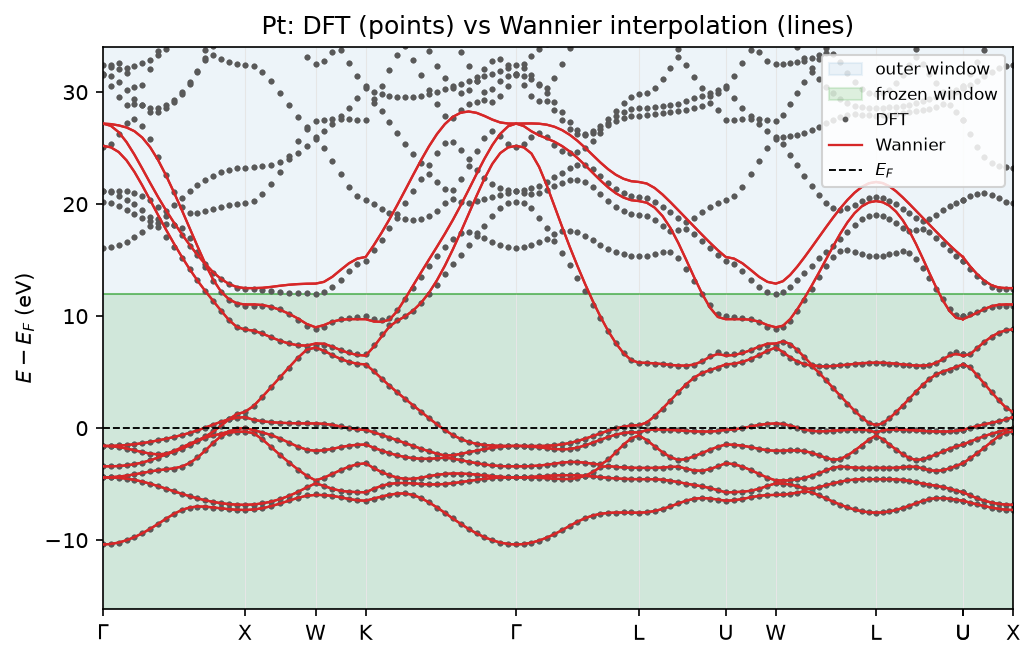

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 4828 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'pt_scdm', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(0.0, 60.0), frozen_window=(0.0, 30.0), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Pt: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(0.0, 30.0), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** The SAME platinum system tutorial 29 Wannierised with explicit analytic $d;s;p$ projections comes out equally well from SCDM's automatic, projection-free initial guess -- `waw`'s SCDM path (already validated for non-spinor Si in tutorial 27) needed no changes at all to handle a noncollinear, spin-orbit-coupled metal. See `project_waw.md`'s tutorial31 entry for the cross-validation record against real `wannier90.x` on this exact system.